# Uygulamalı Makine Öğrenmesi
## Bölüm 1 — K-En Yakın Komşu (K-Nearest Neighbors / KNN)

---

> **Ders Notu Bilgileri**  
> - **Düzey:** Lisans 3-4. Sınıf & Yüksek Lisans  
> - **Süre:** ~3 ders saati (teorik + uygulama)  
> - **Önkoşul:** Python temelleri, NumPy, Pandas, EDA bilgisi  
> - **Kullanılan Kütüphaneler:** NumPy, Pandas, Scikit-learn, Plotly, Seaborn, Matplotlib, Altair  

---

## İçindekiler

| # | Konu | Tür |
|---|------|-----|
| 1 | Kütüphane Kurulumu & İçe Aktarma | Kod |
| 2 | KNN Nedir? Sezgisel Giriş | Teori |
| 3 | Matematiksel Arka Plan: Uzaklık Metrikleri | Teori + Kod |
| 4 | Adım Adım KNN Algoritması | Teori + Görsel |
| 5 | Kullanılan Veri Setleri ve Kaynaklar | Bilgi |
| 6 | Keşifsel Veri Analizi (EDA) | Kod |
| 7 | Veri Ön İşleme | Kod |
| 8 | KNN — Sıfırdan Uygulama (NumPy) | Kod |
| 9 | KNN — Scikit-learn ile Uygulama | Kod |
| 10 | Model Değerlendirme Metrikleri | Kod |
| 11 | K Değerinin Önemi: Hiperparametre Analizi | Kod |
| 12 | Karar Sınırları Görselleştirmesi | Kod |
| 13 | Uzaklık Metriklerinin Karşılaştırması | Kod |
| 14 | Özellik Ölçeklendirmenin Önemi | Kod |
| 15 | KNN ile Regresyon | Kod |
| 16 | Gerçek Dünya Uygulaması | Kod |
| 17 | Avantajlar, Dezavantajlar ve Ne Zaman Kullanılır? | Teori |
| 18 | Özet ve Sonraki Adımlar | Özet |

---
## 1. Kütüphane Kurulumu & İçe Aktarma

Aşağıdaki hücreyi çalıştırarak gerekli kütüphaneleri kurun. Google Colab kullanıyorsanız büyük çoğunluğu zaten yüklüdür.

In [1]:
# Gerekli kütüphanelerin kurulumu (Colab veya yerel ortam)
# Zaten kuruluysa bu hücreyi atlayabilirsiniz
# !pip install plotly altair seaborn scikit-learn pandas numpy matplotlib -q

In [2]:
# ─────────────────────────────────────────────────────────────
# Temel Bilimsel Hesaplama Kütüphaneleri
# ─────────────────────────────────────────────────────────────
import numpy as np                        # Sayısal işlemler, matris hesapları
import pandas as pd                       # Veri çerçevesi işlemleri

# ─────────────────────────────────────────────────────────────
# Görselleştirme Kütüphaneleri
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt           # Temel grafik çizimi
import matplotlib.colors as mcolors       # Renk yönetimi
import seaborn as sns                     # İstatistiksel görselleştirme
import plotly.graph_objects as go         # İnteraktif grafik (detaylı kontrol)
import plotly.express as px               # İnteraktif grafik (hızlı kullanım)
from plotly.subplots import make_subplots # Çoklu grafik düzeni
import altair as alt                      # Deklaratif görselleştirme

# ─────────────────────────────────────────────────────────────
# Scikit-learn: Veri Setleri
# ─────────────────────────────────────────────────────────────
from sklearn.datasets import (
    load_iris,          # Iris çiçek veri seti (sınıflandırma)
    load_wine,          # Şarap kalitesi veri seti (sınıflandırma)
    make_classification, # Sentetik sınıflandırma verisi
    make_regression,     # Sentetik regresyon verisi
    make_moons,          # Ay şeklinde sentetik veri
    make_circles         # Daire şeklinde sentetik veri
)

# ─────────────────────────────────────────────────────────────
# Scikit-learn: Ön İşleme
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,    # Eğitim/test bölümü
    cross_val_score,     # Çapraz doğrulama
    GridSearchCV         # Hiperparametre arama
)
from sklearn.preprocessing import (
    StandardScaler,      # Z-score normalizasyonu
    MinMaxScaler,        # Min-max normalizasyonu
    LabelEncoder         # Etiket kodlama
)

# ─────────────────────────────────────────────────────────────
# Scikit-learn: KNN Modelleri
# ─────────────────────────────────────────────────────────────
from sklearn.neighbors import (
    KNeighborsClassifier,  # KNN sınıflandırma
    KNeighborsRegressor    # KNN regresyon
)

# ─────────────────────────────────────────────────────────────
# Scikit-learn: Değerlendirme Metrikleri
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # Doğruluk skoru
    confusion_matrix,        # Karmaşıklık matrisi
    classification_report,   # Sınıflandırma raporu
    roc_curve,               # ROC eğrisi
    roc_auc_score,           # AUC skoru
    mean_squared_error,      # Ortalama kare hata
    r2_score                 # R² skoru
)

# ─────────────────────────────────────────────────────────────
# Diğer Yardımcı Modüller
# ─────────────────────────────────────────────────────────────
from collections import Counter           # Oy sayımı için
import warnings
warnings.filterwarnings('ignore')         # Gereksiz uyarıları gizle

# ─────────────────────────────────────────────────────────────
# Görselleştirme Ayarları
# ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)  # Varsayılan grafik boyutu
plt.rcParams['font.family'] = 'DejaVu Sans'

# Tekrarlanabilirlik için rastgele tohum değeri
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi!
   NumPy: 2.0.2
   Pandas: 2.2.2


---
## 2. KNN Nedir? Sezgisel Giriş

### Günlük Hayattan Analoji

> *"Bana arkadaşlarını söyle, sana kim olduğunu söyleyeyim."*

KNN (K-En Yakın Komşu), en temel makine öğrenmesi algoritmalarından biridir. Temel fikir son derece basittir:

**Yeni bir örnek sınıflandırmak istediğimizde, eğitim setindeki en yakın K komşusuna bakarak çoğunluk oyunu kullanırız.**

---

### Örnek Senaryo

Bir hastanın kanser hastası olup olmadığını tahmin etmek istiyoruz. Elimizde binlerce geçmiş hasta kaydı var. KNN şöyle çalışır:

1. Yeni hastanın özelliklerini (yaş, tümör büyüklüğü vb.) belirle
2. Tüm eğitim örneklerine olan uzaklığı hesapla
3. En yakın K hastayı bul
4. Bu K hastanın çoğunluğunun sınıfını tahmin et

---

### KNN'in Temel Özellikleri

| Özellik | Açıklama |
|---------|----------|
| **Tür** | Denetimli Öğrenme (Supervised Learning) |
| **Görev** | Sınıflandırma (Classification) + Regresyon (Regression) |
| **Öğrenme Türü** | Tembel Öğrenme (Lazy Learning) — Model eğitim sırasında öğrenmez |
| **Parametrik mi?** | Parametrik olmayan (Non-parametric) |
| **Ana Hiperparametre** | K (komşu sayısı), uzaklık metriği |
| **Bellek Gereksinimleri** | Yüksek — tüm eğitim verisini saklar |

---

### Neden "Tembel Öğrenme" (Lazy Learning)?

KNN, eğitim aşamasında hiçbir şey "öğrenmez" — sadece veriyi hafızada saklar. Gerçek hesaplama, **tahmin (predict) aşamasında** gerçekleşir. Bu nedenle:
- **Eğitim hızı:** O(1) — çok hızlı  
- **Tahmin hızı:** O(n × d) — yavaş olabilir (n: örnek sayısı, d: boyut sayısı)

---
## 3. Matematiksel Arka Plan: Uzaklık Metrikleri

KNN'in kalbi uzaklık hesabıdır. "Yakın" demek ne demektir?

---

### 3.1 Öklid Uzaklığı (Euclidean Distance)

En yaygın kullanılan uzaklık metriği. İki nokta arasındaki düz çizgi mesafesidir:

$$d_{Euclidean}(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**2 boyutlu özel hali:**
$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

---

### 3.2 Manhattan Uzaklığı (L1 Norm)

Şehir bloklarında yürüyüş gibi düşünün — yalnızca yatay ve dikey hareket:

$$d_{Manhattan}(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$$

---

### 3.3 Minkowski Uzaklığı (Genelleştirilmiş)

Öklid ve Manhattan'ı kapsayan genel form:

$$d_{Minkowski}(\mathbf{x}, \mathbf{y}) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}$$

- $p = 1$ → Manhattan uzaklığı  
- $p = 2$ → Öklid uzaklığı  
- $p \to \infty$ → Chebyshev uzaklığı

---

### 3.4 Chebyshev Uzaklığı

Tüm boyutlardaki maksimum fark:

$$d_{Chebyshev}(\mathbf{x}, \mathbf{y}) = \max_{i} |x_i - y_i|$$

---

### 3.5 Kosinüs Benzerliği (Cosine Similarity)

Metin madenciliğinde sıklıkla kullanılır — büyüklük yerine **yön** karşılaştırılır:

$$similarity = \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|} = \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum x_i^2} \cdot \sqrt{\sum y_i^2}}$$

Uzaklığa dönüştürmek için: $d_{cosine} = 1 - similarity$

In [3]:
# ─────────────────────────────────────────────────────────────
# Uzaklık Metriklerinin Python ile Hesaplanması
# ─────────────────────────────────────────────────────────────

# İki örnek nokta tanımlıyoruz
x = np.array([2, 4, 6])
y = np.array([1, 3, 5])

# ── Öklid Uzaklığı ──────────────────────────────────────────
oklid = np.sqrt(np.sum((x - y) ** 2))
print(f"🔵 Öklid Uzaklığı:     {oklid:.4f}")

# ── Manhattan Uzaklığı ───────────────────────────────────────
manhattan = np.sum(np.abs(x - y))
print(f"🔴 Manhattan Uzaklığı: {manhattan:.4f}")

# ── Minkowski Uzaklığı (p=3) ─────────────────────────────────
p = 3
minkowski = np.sum(np.abs(x - y) ** p) ** (1 / p)
print(f"🟢 Minkowski (p=3):    {minkowski:.4f}")

# ── Chebyshev Uzaklığı ───────────────────────────────────────
chebyshev = np.max(np.abs(x - y))
print(f"🟠 Chebyshev Uzaklığı: {chebyshev:.4f}")

# ── Kosinüs Benzerliği ───────────────────────────────────────
cosine_sim = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
cosine_dist = 1 - cosine_sim
print(f"🟣 Kosinüs Benzerliği: {cosine_sim:.4f}  →  Uzaklık: {cosine_dist:.4f}")

# ── Scipy ile doğrulama ──────────────────────────────────────
from scipy.spatial.distance import euclidean, cityblock, chebyshev as cheby, cosine
print("\n📌 Scipy ile doğrulama:")
print(f"   Öklid (scipy):     {euclidean(x, y):.4f}")
print(f"   Manhattan (scipy): {cityblock(x, y):.4f}")
print(f"   Chebyshev (scipy): {cheby(x, y):.4f}")

🔵 Öklid Uzaklığı:     1.7321
🔴 Manhattan Uzaklığı: 3.0000
🟢 Minkowski (p=3):    1.4422
🟠 Chebyshev Uzaklığı: 1.0000
🟣 Kosinüs Benzerliği: 0.9939  →  Uzaklık: 0.0061

📌 Scipy ile doğrulama:
   Öklid (scipy):     1.7321
   Manhattan (scipy): 3.0000
   Chebyshev (scipy): 1.0000


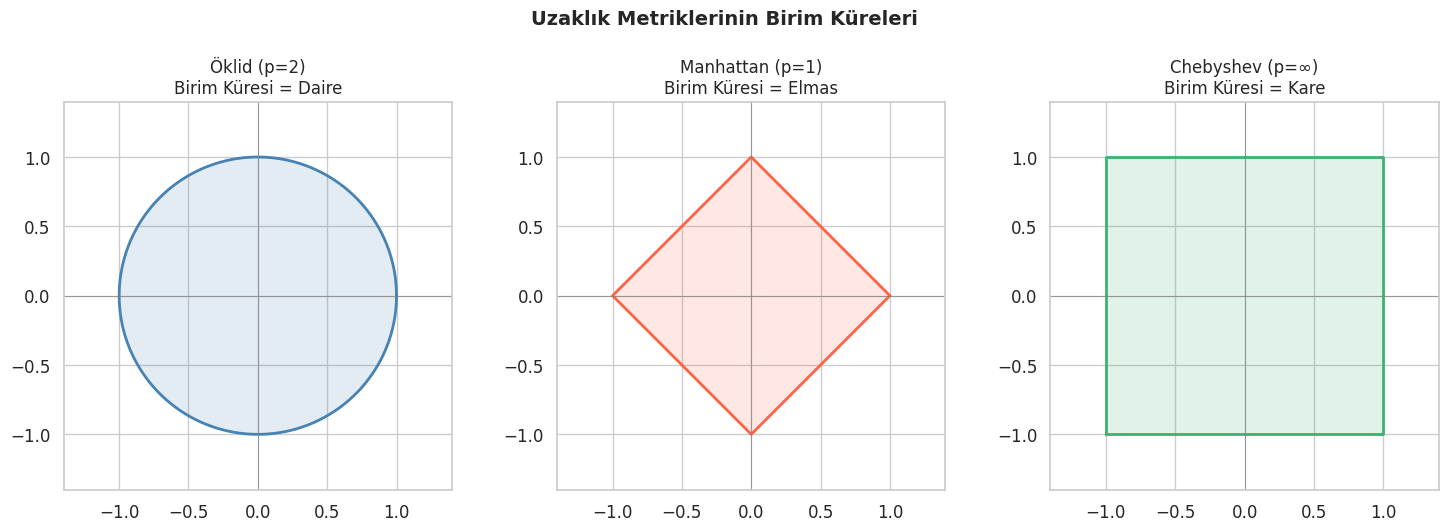

💡 Not: Her metrik farklı bir 'şekil' olarak yakınlığı tanımlar.


In [4]:
# ─────────────────────────────────────────────────────────────
# Uzaklık Metriklerinin 2D Görselleştirmesi (Seaborn + Matplotlib)
# ─────────────────────────────────────────────────────────────
# Her metriğin "birim küresi" farklı bir şekle sahiptir
# Bu görsel, metriklerin geometrik anlamını ortaya koyar

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Uzaklık Metriklerinin Birim Küreleri', fontsize=14, fontweight='bold', y=1.02)

# Theta açı değerleri
theta = np.linspace(0, 2 * np.pi, 300)

# ── Öklid (p=2): Daire ──────────────────────────────────────
ax = axes[0]
x_circle = np.cos(theta)   # Birim çember: r=1
y_circle = np.sin(theta)
ax.plot(x_circle, y_circle, color='steelblue', linewidth=2)
ax.fill(x_circle, y_circle, alpha=0.15, color='steelblue')
ax.set_title('Öklid (p=2)\nBirim Küresi = Daire', fontsize=12)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)

# ── Manhattan (p=1): Elmas ───────────────────────────────────
ax = axes[1]
# Manhattan birim küresi: |x| + |y| = 1 → Elmas şekli
x_diamond = np.array([1, 0, -1, 0, 1])
y_diamond = np.array([0, 1, 0, -1, 0])
ax.plot(x_diamond, y_diamond, color='tomato', linewidth=2)
ax.fill(x_diamond, y_diamond, alpha=0.15, color='tomato')
ax.set_title('Manhattan (p=1)\nBirim Küresi = Elmas', fontsize=12)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)

# ── Chebyshev (p=∞): Kare ────────────────────────────────────
ax = axes[2]
# Chebyshev birim küresi: max(|x|,|y|) = 1 → Kare
x_square = np.array([-1, 1, 1, -1, -1])
y_square = np.array([-1, -1, 1, 1, -1])
ax.plot(x_square, y_square, color='mediumseagreen', linewidth=2)
ax.fill(x_square, y_square, alpha=0.15, color='mediumseagreen')
ax.set_title('Chebyshev (p=∞)\nBirim Küresi = Kare', fontsize=12)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)

plt.tight_layout()
plt.savefig('uzaklik_birimleri.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Not: Her metrik farklı bir 'şekil' olarak yakınlığı tanımlar.")

In [5]:
# ─────────────────────────────────────────────────────────────
# Plotly Express ile İnteraktif Uzaklık Karşılaştırması
# ─────────────────────────────────────────────────────────────
# Sabit bir merkez noktasından rastgele noktalara uzaklık hesaplayarak
# farklı metriklerin nasıl farklı sıralamalar ürettiğini gösteriyoruz

np.random.seed(RANDOM_STATE)

# Merkez nokta
center = np.array([5.0, 5.0])

# 30 adet rastgele nokta üret
points = np.random.uniform(0, 10, size=(30, 2))

# Her nokta için farklı uzaklık metriklerini hesapla
data = []
for i, p in enumerate(points):
    d_oklid    = np.sqrt(np.sum((p - center) ** 2))   # Öklid
    d_manhattan = np.sum(np.abs(p - center))           # Manhattan
    d_cheby    = np.max(np.abs(p - center))            # Chebyshev
    data.append({
        'Nokta': f'P{i+1}',
        'x': p[0], 'y': p[1],
        'Öklid': round(d_oklid, 3),
        'Manhattan': round(d_manhattan, 3),
        'Chebyshev': round(d_cheby, 3)
    })

df_dist = pd.DataFrame(data)

# En yakın 5 komşuyu her metriğe göre işaretle
k5_oklid    = set(df_dist.nsmallest(5, 'Öklid')['Nokta'])
k5_manhattan = set(df_dist.nsmallest(5, 'Manhattan')['Nokta'])

# Scatter plot — noktaların koordinatları, hover'da uzaklık bilgisi
fig = px.scatter(
    df_dist, x='x', y='y',
    hover_name='Nokta',
    hover_data={'Öklid': ':.3f', 'Manhattan': ':.3f', 'Chebyshev': ':.3f'},
    color='Öklid',           # Öklid uzaklığına göre renklendirme
    color_continuous_scale='RdYlGn_r',
    size=[8]*len(df_dist),
    title='Merkez Noktadan Uzaklıklar (Renk = Öklid Uzaklığı)'
)

# Merkez noktayı ekle
fig.add_trace(go.Scatter(
    x=[center[0]], y=[center[1]],
    mode='markers+text',
    marker=dict(symbol='star', size=18, color='black'),
    text=['Merkez (5,5)'], textposition='top right',
    name='Merkez', showlegend=True
))

fig.update_layout(
    height=450,
    xaxis_title='x', yaxis_title='y',
    coloraxis_colorbar_title='Öklid'
)
fig.show()
print("💡 İpucu: Her noktanın üzerine gelerek tüm uzaklık metriklerini görebilirsiniz.")

💡 İpucu: Her noktanın üzerine gelerek tüm uzaklık metriklerini görebilirsiniz.


---
## 4. Adım Adım KNN Algoritması

### Sınıflandırma için KNN Adımları:

```
GİRDİ: Eğitim seti (X_train, y_train), Yeni örnek (x_query), K değeri
ÇIKTI: Tahmin edilen sınıf (y_pred)

ADIM 1: x_query ile tüm eğitim örnekleri arasındaki uzaklıkları hesapla
        d_i = distance(x_query, x_train_i)  ∀i ∈ {1,...,N}

ADIM 2: Uzaklıkları küçükten büyüğe sırala
        sorted_indices = argsort(distances)

ADIM 3: En küçük K uzaklığa sahip komşuları seç
        k_nearest = sorted_indices[:K]

ADIM 4: Bu K komşunun sınıf etiketlerini al
        k_labels = y_train[k_nearest]

ADIM 5: Çoğunluk oyuyla tahmin et (mode)
        y_pred = mode(k_labels)
```

### Regresyon için KNN:

Adımlar aynı, sadece **ADIM 5** değişir:

```
ADIM 5 (Regresyon): K komşunun hedef değerlerinin ortalamasını al
        y_pred = mean(y_train[k_nearest])
```

### Ağırlıklı KNN:

Komşulara eşit oy vermek yerine, yakın komşulara daha fazla ağırlık verilebilir:

$$w_i = \frac{1}{d_i + \epsilon}$$

Burada $\epsilon$ sıfıra bölünmeyi önler (örnek eğitim setinde mevcutsa).

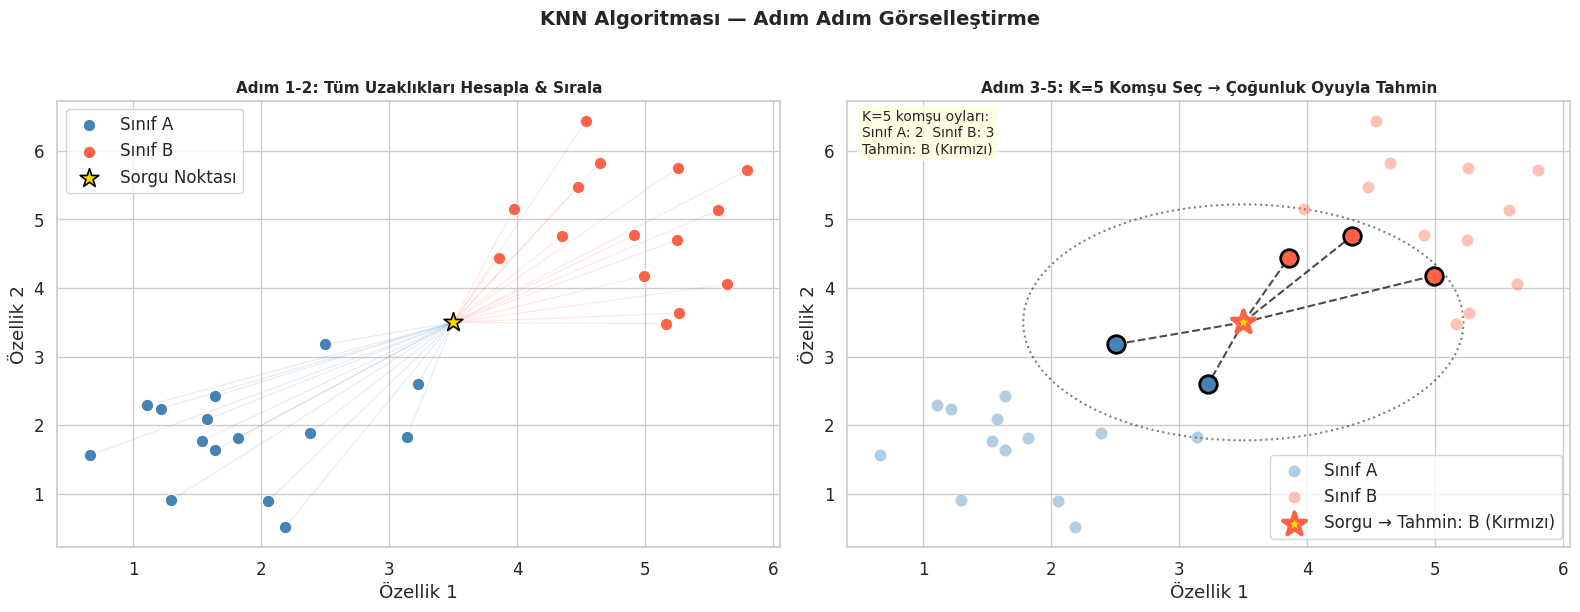


 Sonuç: K=5 komşudan 2 tanesi Sınıf A, 3 tanesi Sınıf B
✅ Tahmin edilen sınıf: B (Kırmızı)


In [6]:
# ─────────────────────────────────────────────────────────────
# KNN Algoritmasının Adım Adım Görsel Açıklaması
# Seaborn + Matplotlib ile 2D örnek
# ─────────────────────────────────────────────────────────────

np.random.seed(RANDOM_STATE)

# ── Basit 2 sınıflı küçük veri seti oluştur ──────────────────
n_per_class = 15

# Sınıf A: Mavi (sol alt bölge)
class_A = np.random.multivariate_normal([2, 2], [[0.6, 0], [0, 0.6]], n_per_class)
# Sınıf B: Kırmızı (sağ üst bölge)
class_B = np.random.multivariate_normal([5, 5], [[0.6, 0], [0, 0.6]], n_per_class)

# Tüm noktaları birleştir
X_demo = np.vstack([class_A, class_B])
y_demo = np.array([0]*n_per_class + [1]*n_per_class)

# Yeni sorgu noktası
query_point = np.array([3.5, 3.5])
K = 5  # Komşu sayısı

# ── Tüm uzaklıkları hesapla ───────────────────────────────────
distances = np.sqrt(np.sum((X_demo - query_point) ** 2, axis=1))

# En yakın K komşuyu bul
k_indices = np.argsort(distances)[:K]
k_distances = distances[k_indices]
k_labels = y_demo[k_indices]

# Çoğunluk oyuyla tahmin
from collections import Counter
vote_counts = Counter(k_labels)
prediction = vote_counts.most_common(1)[0][0]
sınıf_isimleri = {0: 'A (Mavi)', 1: 'B (Kırmızı)'}

# ── Görselleştir ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Sol: Tüm noktalara uzaklık ────────────────────────────
ax = axes[0]
ax.scatter(class_A[:, 0], class_A[:, 1], c='steelblue', s=80,
           label='Sınıf A', edgecolors='white', linewidth=0.8, zorder=3)
ax.scatter(class_B[:, 0], class_B[:, 1], c='tomato', s=80,
           label='Sınıf B', edgecolors='white', linewidth=0.8, zorder=3)
ax.scatter(*query_point, c='gold', s=200, marker='*',
           label='Sorgu Noktası', edgecolors='black', linewidth=1.2, zorder=5)

# Her noktaya ince çizgi çiz (mesafe görselleştirmesi)
for i in range(len(X_demo)):
    color = 'steelblue' if y_demo[i] == 0 else 'tomato'
    ax.plot([query_point[0], X_demo[i, 0]],
            [query_point[1], X_demo[i, 1]],
            color=color, alpha=0.15, linewidth=0.8)

ax.set_title('Adım 1-2: Tüm Uzaklıkları Hesapla & Sırala', fontsize=11, fontweight='bold')
ax.legend()
ax.set_xlabel('Özellik 1'); ax.set_ylabel('Özellik 2')

# ─── Sağ: K en yakın komşu ──────────────────────────────────
ax = axes[1]
ax.scatter(class_A[:, 0], class_A[:, 1], c='steelblue', s=80,
           label='Sınıf A', edgecolors='white', linewidth=0.8, zorder=3, alpha=0.4)
ax.scatter(class_B[:, 0], class_B[:, 1], c='tomato', s=80,
           label='Sınıf B', edgecolors='white', linewidth=0.8, zorder=3, alpha=0.4)

# K komşuları vurgula
for idx in k_indices:
    color = 'steelblue' if y_demo[idx] == 0 else 'tomato'
    ax.scatter(*X_demo[idx], s=160, c=color, edgecolors='black',
               linewidth=2, zorder=4)
    ax.plot([query_point[0], X_demo[idx, 0]],
            [query_point[1], X_demo[idx, 1]],
            color='black', linewidth=1.5, linestyle='--', alpha=0.7)

# Sorgu noktası
pred_color = 'steelblue' if prediction == 0 else 'tomato'
ax.scatter(*query_point, c='gold', s=300, marker='*',
           label=f'Sorgu → Tahmin: {sınıf_isimleri[prediction]}',
           edgecolors=pred_color, linewidth=3, zorder=5)

# K komşuların etrafında daire
max_k_dist = k_distances[-1] * 1.05
circle = plt.Circle(query_point, max_k_dist, fill=False,
                    color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax.add_patch(circle)

# Oy sayısını göster
ax.text(0.02, 0.98,
        f'K={K} komşu oyları:\nSınıf A: {vote_counts.get(0,0)}  Sınıf B: {vote_counts.get(1,0)}\nTahmin: {sınıf_isimleri[prediction]}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title(f'Adım 3-5: K={K} Komşu Seç → Çoğunluk Oyuyla Tahmin', fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlabel('Özellik 1'); ax.set_ylabel('Özellik 2')

plt.suptitle('KNN Algoritması — Adım Adım Görselleştirme', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Sonuç: K={K} komşudan {vote_counts.get(0,0)} tanesi Sınıf A, {vote_counts.get(1,0)} tanesi Sınıf B")
print(f"✅ Tahmin edilen sınıf: {sınıf_isimleri[prediction]}")

---
## 5. Kullanılan Veri Setleri ve Kaynaklar

Bu ders notunda aşağıdaki veri setleri kullanılacaktır. **Her veri setini nereden bulduğunuzu ve nasıl erişebileceğinizi bilmek akademik açıdan önemlidir.**

---

### Veri Seti 1: Iris Çiçek Veri Seti

| Bilgi | Detay |
|-------|-------|
| **Kaynak** | R.A. Fisher (1936), UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/ml/datasets/iris |
| **Scikit-learn** | `sklearn.datasets.load_iris()` |
| **Örnek Sayısı** | 150 (her sınıftan 50) |
| **Özellik Sayısı** | 4 (sepal length/width, petal length/width) |
| **Sınıf Sayısı** | 3 (Setosa, Versicolor, Virginica) |
| **Kullanım Amacı** | Temel KNN sınıflandırma |
| **Lisans** | Public Domain |

---

### Veri Seti 2: Şarap Kalitesi (Wine) Veri Seti

| Bilgi | Detay |
|-------|-------|
| **Kaynak** | Forina et al. (1986), UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/ml/datasets/wine |
| **Scikit-learn** | `sklearn.datasets.load_wine()` |
| **Örnek Sayısı** | 178 |
| **Özellik Sayısı** | 13 (kimyasal özellikler) |
| **Sınıf Sayısı** | 3 (şarap çeşitleri) |
| **Kullanım Amacı** | Gerçek dünya uygulaması, özellik ölçeklendirme önemi |
| **Lisans** | Public Domain |

---

### Veri Seti 3: Sentetik Veri Setleri

| Veri Seti | Scikit-learn Fonksiyonu | Amaç |
|-----------|------------------------|------|
| Moons | `make_moons()` | KNN'in doğrusal olmayan sınırlara adaptasyonu |
| Circles | `make_circles()` | İç içe geçmiş sınıf yapıları |
| Classification | `make_classification()` | Genel sınıflandırma performansı |
| Regression | `make_regression()` | KNN regresyon uygulaması |

> **💡 Not:** Sentetik veriler tamamen kontrol edilebilir olduğundan öğretim amaçlı idealdir. Gerçek gürültü, örtüşme ve sınır karmaşıklığını ayarlayabilirsiniz.

In [7]:
# ─────────────────────────────────────────────────────────────
# Iris Veri Setini Yükleme ve Temel Bilgiler
# ─────────────────────────────────────────────────────────────

# Scikit-learn'den Iris veri setini yükle
iris = load_iris()

# Pandas DataFrame'e dönüştür (daha okunabilir çalışma için)
df_iris = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names  # ['sepal length (cm)', 'sepal width (cm)', ...]
)

# Hedef sütunu ekle (0, 1, 2 → Setosa, Versicolor, Virginica)
df_iris['target'] = iris.target
df_iris['species'] = df_iris['target'].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

# Sütun isimlerini kısalt (daha kolay erişim için)
df_iris.columns = ['sepal_length', 'sepal_width', 'petal_length',
                   'petal_width', 'target', 'species']

# ── Veri setine temel bakış ───────────────────────────────────
print("=" * 55)
print(" IRIS VERİ SETİ — TEMEL BİLGİLER")
print("=" * 55)
print(f"  Kaynak   : UCI ML Repository (Fisher, 1936)")
print(f"  Boyut    : {df_iris.shape[0]} satır × {df_iris.shape[1]-2} özellik + 1 hedef")
print(f"  Eksik    : {df_iris.isnull().sum().sum()} değer")
print(f"  Sınıflar : {list(iris.target_names)}")
print("=" * 55)
print()

# İlk 5 satırı göster
print("İlk 5 satır:")
df_iris.head()

 IRIS VERİ SETİ — TEMEL BİLGİLER
  Kaynak   : UCI ML Repository (Fisher, 1936)
  Boyut    : 150 satır × 4 özellik + 1 hedef
  Eksik    : 0 değer
  Sınıflar : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

İlk 5 satır:


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---
## 6. Keşifsel Veri Analizi (EDA)

Modeli kurmadan önce verimizi anlamamız gerekir. Dağılımları, korelasyonları ve sınıf dengelerini inceleyelim.

In [8]:
# ─────────────────────────────────────────────────────────────
# Temel İstatistikler — Her sınıf için ayrı ayrı
# ─────────────────────────────────────────────────────────────

# Her sınıf için özellik ortalamalarını karşılaştır
desc_by_class = df_iris.groupby('species')[['sepal_length', 'sepal_width',
                                             'petal_length', 'petal_width']].agg(
    ['mean', 'std', 'min', 'max']
).round(2)

print("Sınıflara Göre İstatistikler:")
display(desc_by_class)

# Sınıf dağılımı
print("\nSınıf Dağılımı:")
print(df_iris['species'].value_counts())

Sınıflara Göre İstatistikler:


sepal_length                 sepal_width                  \
                   mean   std  min  max        mean   std  min  max   
species                                                               
setosa             5.01  0.35  4.3  5.8        3.43  0.38  2.3  4.4   
versicolor         5.94  0.52  4.9  7.0        2.77  0.31  2.0  3.4   
virginica          6.59  0.64  4.9  7.9        2.97  0.32  2.2  3.8   

           petal_length                 petal_width                  
                   mean   std  min  max        mean   std  min  max  
species                                                              
setosa             1.46  0.17  1.0  1.9        0.25  0.11  0.1  0.6  
versicolor         4.26  0.47  3.0  5.1        1.33  0.20  1.0  1.8  
virginica          5.55  0.55  4.5  6.9        2.03  0.27  1.4  2.5


Sınıf Dağılımı:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [9]:
# ─────────────────────────────────────────────────────────────
# Plotly Express ile İnteraktif Dağılım Matrisi (Pairplot)
# ─────────────────────────────────────────────────────────────
# Tüm özellik çiftlerini aynı anda görselleştirir
# KNN için hangi özellik çiftlerinin sınıfları iyi ayırdığını gösterir

fig = px.scatter_matrix(
    df_iris,
    dimensions=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    color='species',
    title='Iris Veri Seti — Tüm Özellik Çiftleri (İnteraktif)',
    labels={
        'sepal_length': 'Sepal Uzunluk',
        'sepal_width': 'Sepal Genişlik',
        'petal_length': 'Petal Uzunluk',
        'petal_width': 'Petal Genişlik'
    },
    color_discrete_map={
        'setosa': '#1f77b4',
        'versicolor': '#ff7f0e',
        'virginica': '#2ca02c'
    },
    opacity=0.75
)

fig.update_traces(diagonal_visible=False, showupperhalf=False)
fig.update_layout(height=550, title_x=0.5)
fig.show()
print("💡 Gözlem: Petal özellikleri (uzunluk/genişlik) sınıfları çok daha iyi ayırıyor!")

💡 Gözlem: Petal özellikleri (uzunluk/genişlik) sınıfları çok daha iyi ayırıyor!


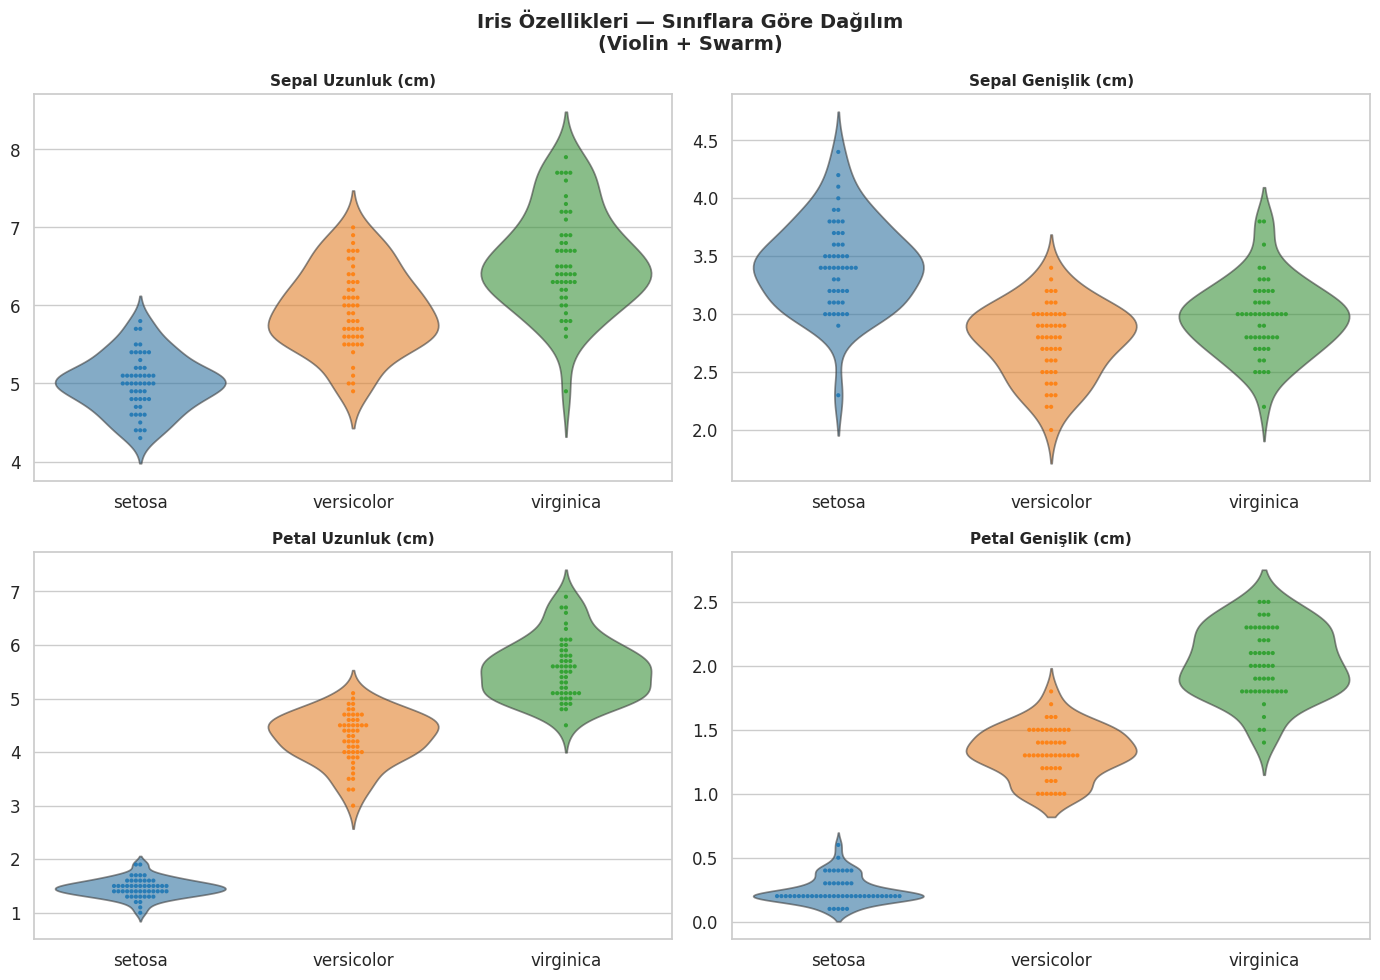

💡 Violet şekli = dağılım yoğunluğu; noktalar = gerçek örnekler


In [10]:
# ─────────────────────────────────────────────────────────────
# Seaborn Violin + Swarm Plot Kombinasyonu
# Her özelliğin sınıflara göre dağılımını gösterir
# ─────────────────────────────────────────────────────────────

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_labels = ['Sepal Uzunluk (cm)', 'Sepal Genişlik (cm)',
                  'Petal Uzunluk (cm)', 'Petal Genişlik (cm)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Özellikleri — Sınıflara Göre Dağılım\n(Violin + Swarm)',
             fontsize=14, fontweight='bold')

palette = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axes[i // 2][i % 2]

    # Arka plan: violin plot (dağılım şekli)
    sns.violinplot(
        data=df_iris, x='species', y=feature,
        palette=palette, ax=ax,
        inner=None, alpha=0.6
    )

    # Ön plan: swarm plot (gerçek nokta konumları)
    sns.swarmplot(
        data=df_iris, x='species', y=feature,
        palette=palette, ax=ax,
        size=3, alpha=0.9
    )

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()
print("💡 Violet şekli = dağılım yoğunluğu; noktalar = gerçek örnekler")

In [11]:
# ─────────────────────────────────────────────────────────────
# Korelasyon Isı Haritası (Altair ile)
# ─────────────────────────────────────────────────────────────
# Özellikler arasındaki ilişkileri görmek, multicollinearity analizi için

# Korelasyon matrisini hesapla
corr_matrix = df_iris[features].corr().round(3)

# Altair için "long format" veri hazırla
corr_long = corr_matrix.reset_index().melt(
    id_vars='index',
    var_name='variable',
    value_name='correlation'
)
corr_long.columns = ['var1', 'var2', 'corr']

# Kısa isimler
short_names = {
    'sepal_length': 'Sepal L.',
    'sepal_width': 'Sepal W.',
    'petal_length': 'Petal L.',
    'petal_width': 'Petal W.'
}
corr_long['var1'] = corr_long['var1'].map(short_names)
corr_long['var2'] = corr_long['var2'].map(short_names)

# Altair ısı haritası
heatmap = alt.Chart(corr_long, title='Özellikler Arası Korelasyon Matrisi').mark_rect().encode(
    x=alt.X('var1:N', title='', sort=None,
             axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('var2:N', title='', sort=None),
    color=alt.Color(
        'corr:Q',
        scale=alt.Scale(scheme='redblue', domain=[-1, 1]),
        legend=alt.Legend(title='Korelasyon')
    ),
    tooltip=['var1:N', 'var2:N', alt.Tooltip('corr:Q', format='.3f')]
).properties(width=350, height=300)

# Değer etiketleri
text = heatmap.mark_text(fontSize=12, fontWeight='bold').encode(
    text=alt.Text('corr:Q', format='.2f'),
    color=alt.condition(
        alt.datum.corr > 0.5,
        alt.value('white'),
        alt.value('black')
    )
)

(heatmap + text).configure_title(fontSize=14).show()

print("💡 Yüksek korelasyon (±0.8+): Petal uzunluk & genişlik birbirine çok bağlı")

alt.LayerChart(...)

💡 Yüksek korelasyon (±0.8+): Petal uzunluk & genişlik birbirine çok bağlı


---
## 7. Veri Ön İşleme

KNN, **uzaklık tabanlı** bir algoritma olduğundan özellik ölçeklendirme **kritik** önem taşır.  
Bu bölümde hem ölçeklendirme hem de eğitim/test bölümünü gerçekleştireceğiz.

### Neden Ölçeklendirme Gerekli?

Bir özelliğin değer aralığı 0-1 iken başka bir özellik 0-1000 aralığındaysa, büyük değer aralığına sahip özellik uzaklık hesabını domine eder. KNN tamamen bu uzaklıklara dayandığından, bu durum yanlı sonuçlara yol açar.

**Bölüm 14'te bu etkiyi sayısal olarak göstereceğiz.**

In [12]:
# ─────────────────────────────────────────────────────────────
# Veri Ön İşleme: Train/Test Split + Ölçeklendirme
# ─────────────────────────────────────────────────────────────

# Ham özellik matrisi ve hedef vektör
X = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df_iris['target'].values

# ── Eğitim ve Test Setine Böl (%80 eğitim, %20 test) ─────────
# stratify=y: Sınıf oranlarının her iki sette de korunması için
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # Sınıf dengesini korur
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti  : {X_test.shape[0]} örnek")

# Sınıf dağılımını kontrol et
print(f"\nEğitim sınıf dağılımı: {Counter(y_train)}")
print(f"Test sınıf dağılımı  : {Counter(y_test)}")

Eğitim seti: 120 örnek
Test seti  : 30 örnek

Eğitim sınıf dağılımı: Counter({np.int64(0): 40, np.int64(2): 40, np.int64(1): 40})
Test sınıf dağılımı  : Counter({np.int64(0): 10, np.int64(2): 10, np.int64(1): 10})


In [13]:
# ─────────────────────────────────────────────────────────────
# StandardScaler ile Özellik Ölçeklendirme
# Z-score normalizasyonu: x' = (x - μ) / σ
# ─────────────────────────────────────────────────────────────

# ÖNEMLİ: Scaler'ı SADECE eğitim verisiyle fit et!
# Test verisine fit etmek = data leakage (veri sızıntısı)
scaler = StandardScaler()

# fit_transform: hem istatistikleri öğren hem dönüştür (eğitim)
X_train_scaled = scaler.fit_transform(X_train)

# transform: sadece dönüştür, öğrenme YOK (test)
X_test_scaled  = scaler.transform(X_test)

# ── Ölçeklendirme öncesi ve sonrası karşılaştırma ─────────────
print("ÖLÇEKLENDIRME ÖNCESİ (Ham Değerler):")
print(f"  Ortalama: {X_train.mean(axis=0).round(2)}")
print(f"  Std:      {X_train.std(axis=0).round(2)}")
print(f"  Min:      {X_train.min(axis=0).round(2)}")
print(f"  Max:      {X_train.max(axis=0).round(2)}")

print("\nÖLÇEKLENDIRME SONRASI (Z-Score):")
print(f"  Ortalama: {X_train_scaled.mean(axis=0).round(4)}  ← ~0")
print(f"  Std:      {X_train_scaled.std(axis=0).round(4)}   ← ~1")
print(f"  Min:      {X_train_scaled.min(axis=0).round(2)}")
print(f"  Max:      {X_train_scaled.max(axis=0).round(2)}")

ÖLÇEKLENDIRME ÖNCESİ (Ham Değerler):
  Ortalama: [5.84 3.05 3.77 1.2 ]
  Std:      [0.84 0.45 1.76 0.76]
  Min:      [4.3 2.  1.1 0.1]
  Max:      [7.9 4.4 6.9 2.5]

ÖLÇEKLENDIRME SONRASI (Z-Score):
  Ortalama: [-0. -0.  0.  0.]  ← ~0
  Std:      [1. 1. 1. 1.]   ← ~1
  Min:      [-1.84 -2.35 -1.52 -1.45]
  Max:      [2.46 3.03 1.78 1.71]


---
## 8. KNN — Sıfırdan Uygulama (NumPy ile)

Scikit-learn kullanmadan önce algoritmayı sıfırdan yazarak içini anlayalım.  
Bu, algoritmanın her adımını kavramak için en etkili yöntemdir.

### Tasarım:
- `fit()`: Veriyi sakla (gerçekten sadece bu kadar!)
- `predict()`: Mesafe hesapla → sırala → K komşu al → oy say

In [14]:
# ─────────────────────────────────────────────────────────────
# Sıfırdan KNN Sınıflandırıcı (Nesne Tabanlı Tasarım)
# ─────────────────────────────────────────────────────────────

class KNNClassifierScratch:
    """
    K-En Yakın Komşu Sınıflandırıcı — Sıfırdan Uygulama

    Parametreler
    -----------
    k         : int   — Komşu sayısı
    metric    : str   — 'euclidean', 'manhattan', 'chebyshev'
    weighted  : bool  — True: 1/d ağırlıklı oy; False: eşit oy
    """

    def __init__(self, k=5, metric='euclidean', weighted=False):
        self.k        = k
        self.metric   = metric
        self.weighted = weighted
        self.X_train  = None
        self.y_train  = None

    def fit(self, X, y):
        """KNN'in 'eğitimi' — sadece veriyi sakla!"""
        self.X_train = np.array(X)  # Eğitim özellik matrisi
        self.y_train = np.array(y)  # Eğitim etiketleri
        return self

    def _compute_distance(self, x1, x2):
        """İki nokta arasındaki uzaklığı hesapla."""
        if self.metric == 'euclidean':
            # L2 normu: √(Σ(x₁ᵢ - x₂ᵢ)²)
            return np.sqrt(np.sum((x1 - x2) ** 2))

        elif self.metric == 'manhattan':
            # L1 normu: Σ|x₁ᵢ - x₂ᵢ|
            return np.sum(np.abs(x1 - x2))

        elif self.metric == 'chebyshev':
            # L∞ normu: max|x₁ᵢ - x₂ᵢ|
            return np.max(np.abs(x1 - x2))

        else:
            raise ValueError(f"Bilinmeyen metrik: {self.metric}")

    def _predict_single(self, x):
        """Tek bir örnek için tahmin."""
        # ── ADIM 1: Tüm eğitim örneklerine uzaklıkları hesapla ──
        distances = np.array([
            self._compute_distance(x, x_train)
            for x_train in self.X_train
        ])

        # ── ADIM 2: Uzaklıkları sırala, en küçük K'yı al ─────────
        k_indices = np.argsort(distances)[:self.k]
        k_distances = distances[k_indices]      # K en küçük mesafe
        k_labels = self.y_train[k_indices]      # K komşunun etiketleri

        # ── ADIM 3: Oy sayımı ─────────────────────────────────────
        if not self.weighted:
            # Eşit oy: Her komşu 1 oy
            votes = Counter(k_labels)
        else:
            # Ağırlıklı oy: Yakın komşuya daha fazla oy
            # ε = 1e-10: 0 mesafeli örneğin bölme hatasını önler
            weights = 1.0 / (k_distances + 1e-10)
            votes = {}
            for label, weight in zip(k_labels, weights):
                votes[label] = votes.get(label, 0) + weight

        # En çok oy alan sınıfı döndür
        return max(votes, key=votes.get)

    def predict(self, X):
        """Birden fazla örnek için toplu tahmin."""
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])

    def score(self, X, y):
        """Doğruluk skoru (Accuracy)."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


print("✅ KNNClassifierScratch sınıfı tanımlandı!")
print("   Desteklenen metrikler: 'euclidean', 'manhattan', 'chebyshev'")
print("   Ağırlıklı oy: weighted=True ile etkinleştirilebilir")

✅ KNNClassifierScratch sınıfı tanımlandı!
   Desteklenen metrikler: 'euclidean', 'manhattan', 'chebyshev'
   Ağırlıklı oy: weighted=True ile etkinleştirilebilir


In [15]:
# ─────────────────────────────────────────────────────────────
# Sıfırdan KNN'i Test Et
# ─────────────────────────────────────────────────────────────

# ── K=5, Öklid metriği, eşit oy ──────────────────────────────
knn_scratch = KNNClassifierScratch(k=5, metric='euclidean', weighted=False)
knn_scratch.fit(X_train_scaled, y_train)

# Tahmin
y_pred_scratch = knn_scratch.predict(X_test_scaled)
acc_scratch = knn_scratch.score(X_test_scaled, y_test)

print(f"K=5, Metrik=Öklid, Ağırlıksız → Doğruluk: {acc_scratch:.4f} ({acc_scratch*100:.1f}%)")

# ── K=5, Öklid metriği, ağırlıklı oy ─────────────────────────
knn_weighted = KNNClassifierScratch(k=5, metric='euclidean', weighted=True)
knn_weighted.fit(X_train_scaled, y_train)
acc_weighted = knn_weighted.score(X_test_scaled, y_test)
print(f"K=5, Metrik=Öklid, Ağırlıklı    → Doğruluk: {acc_weighted:.4f} ({acc_weighted*100:.1f}%)")

# ── Manhattan metriği ─────────────────────────────────────────
knn_manhat = KNNClassifierScratch(k=5, metric='manhattan')
knn_manhat.fit(X_train_scaled, y_train)
acc_manhat = knn_manhat.score(X_test_scaled, y_test)
print(f"K=5, Metrik=Manhattan, Ağırlıksız → Doğruluk: {acc_manhat:.4f} ({acc_manhat*100:.1f}%)")

print("\n✅ Sıfırdan uygulama başarıyla test edildi!")

K=5, Metrik=Öklid, Ağırlıksız → Doğruluk: 0.9333 (93.3%)
K=5, Metrik=Öklid, Ağırlıklı    → Doğruluk: 0.9667 (96.7%)
K=5, Metrik=Manhattan, Ağırlıksız → Doğruluk: 0.9333 (93.3%)

✅ Sıfırdan uygulama başarıyla test edildi!


---
## 9. KNN — Scikit-learn ile Uygulama

Sıfırdan uygulamanın ardından artık profesyonel araç olan Scikit-learn'ü kullanalım.  
Scikit-learn'ün avantajları:
- KD-Tree ve Ball-Tree algoritmaları ile **çok daha hızlı** tahmin (büyük veri setlerinde)
- Tüm Minkowski metrikleri dahil çok daha fazla metrik seçeneği
- Pipeline ile sorunsuz entegrasyon
- Otomatik paralelleştirme (`n_jobs=-1`)

In [16]:
# ─────────────────────────────────────────────────────────────
# Scikit-learn KNN Sınıflandırıcı
# ─────────────────────────────────────────────────────────────

# KNeighborsClassifier parametreleri:
#   n_neighbors : komşu sayısı K (varsayılan=5)
#   weights     : 'uniform' (eşit oy) veya 'distance' (ağırlıklı oy)
#   metric      : uzaklık metriği ('euclidean', 'manhattan', 'minkowski', ...)
#   algorithm   : 'auto', 'ball_tree', 'kd_tree', 'brute'
#   n_jobs      : -1 ile tüm CPU çekirdeklerini kullan

knn_sklearn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='euclidean',
    algorithm='auto',    # Veri boyutuna göre en hızlı algoritmayı seç
    n_jobs=-1            # Paralel hesaplama
)

# Modeli eğit (fit = sadece veriyi sakla + ağaç yapısını kur)
knn_sklearn.fit(X_train_scaled, y_train)

# Test seti üzerinde tahmin yap
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)

# Tahmin olasılıkları (her sınıf için)
y_prob_sklearn = knn_sklearn.predict_proba(X_test_scaled)

# Doğruluk hesapla
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print("=" * 50)
print(" Scikit-learn KNN Sonuçları")
print("=" * 50)
print(f"  K değeri  : {knn_sklearn.n_neighbors}")
print(f"  Metrik    : {knn_sklearn.metric}")
print(f"  Algoritma : {knn_sklearn.algorithm}")
print(f"  Doğruluk  : {acc_sklearn:.4f} ({acc_sklearn*100:.1f}%)")

print(f"\n  Sıfırdan ile karşılaştırma: {acc_scratch:.4f} vs {acc_sklearn:.4f}")
print("  → İkisi de aynı sonucu vermeli ✓")

 Scikit-learn KNN Sonuçları
  K değeri  : 5
  Metrik    : euclidean
  Algoritma : auto
  Doğruluk  : 0.9333 (93.3%)

  Sıfırdan ile karşılaştırma: 0.9333 vs 0.9333
  → İkisi de aynı sonucu vermeli ✓


---
## 10. Model Değerlendirme Metrikleri

Doğruluk (accuracy) tek başına yeterli değildir. Özellikle dengesiz veri setlerinde yanıltıcı olabilir. Aşağıdaki metriklerin hepsini bilmek gerekir:

### Karmaşıklık Matrisi (Confusion Matrix):

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

| Terim | Anlamı |
|-------|--------|
| TP (True Positive) | Doğru pozitif tahmin |
| TN (True Negative) | Doğru negatif tahmin |
| FP (False Positive) | Yanlış pozitif tahmin (Tip I Hata) |
| FN (False Negative) | Yanlış negatif tahmin (Tip II Hata) |

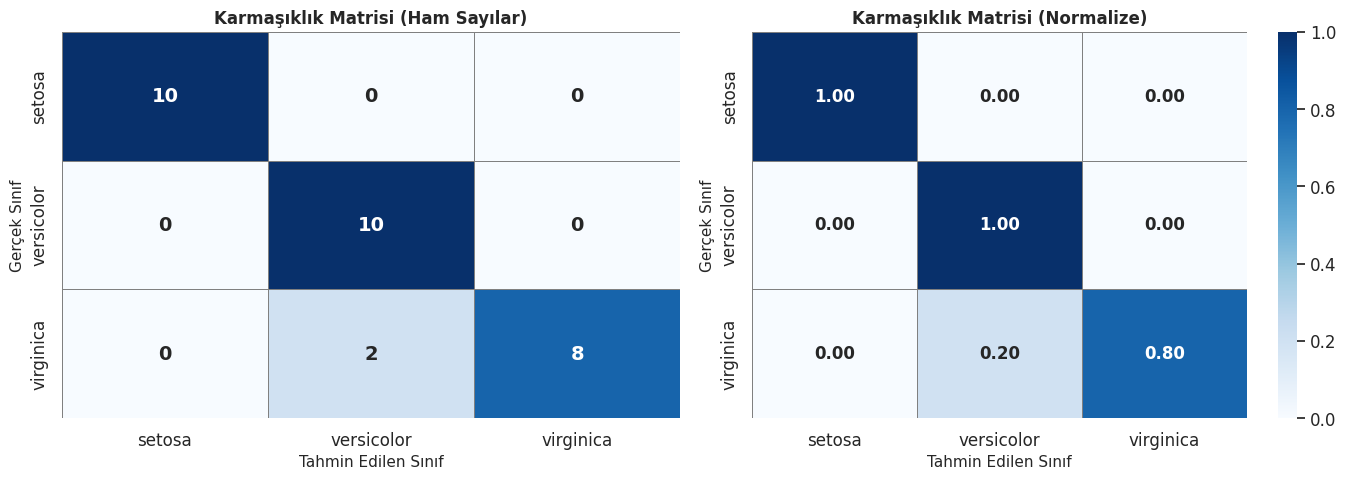

💡 Köşegen elemanlar doğru tahminleri, köşegen dışı elemanlar hataları gösterir.


In [17]:
# ─────────────────────────────────────────────────────────────
# Karmaşıklık Matrisi — Seaborn Isı Haritası
# ─────────────────────────────────────────────────────────────

# Karmaşıklık matrisini hesapla
cm = confusion_matrix(y_test, y_pred_sklearn)
cm_labels = iris.target_names  # ['setosa', 'versicolor', 'virginica']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Sol: Ham Sayılar ──────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels,
    linewidths=0.5, linecolor='gray',
    ax=axes[0], cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Karmaşıklık Matrisi (Ham Sayılar)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=11)
axes[0].set_ylabel('Gerçek Sınıf', fontsize=11)

# ─── Sağ: Normalize (Yüzdeler) ────────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Satır bazında normalize
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels,
    linewidths=0.5, linecolor='gray',
    ax=axes[1], vmin=0, vmax=1,
    annot_kws={'size': 12, 'weight': 'bold'}
)
axes[1].set_title('Karmaşıklık Matrisi (Normalize)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen Sınıf', fontsize=11)
axes[1].set_ylabel('Gerçek Sınıf', fontsize=11)

plt.tight_layout()
plt.show()
print("💡 Köşegen elemanlar doğru tahminleri, köşegen dışı elemanlar hataları gösterir.")

In [18]:
# ─────────────────────────────────────────────────────────────
# Detaylı Sınıflandırma Raporu
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(" DETAYLI SINIFLANDIRMA RAPORU")
print("=" * 60)
report = classification_report(
    y_test, y_pred_sklearn,
    target_names=iris.target_names,
    digits=4
)
print(report)

# Raporu DataFrame'e çevirerek daha iyi göster
report_dict = classification_report(
    y_test, y_pred_sklearn,
    target_names=iris.target_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).T.round(4)
print("\nDataFrame Formatı:")
display(df_report)

 DETAYLI SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30


DataFrame Formatı:


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,10.0000
versicolor,0.8333,1.0000,0.9091,10.0000
virginica,1.0000,0.8000,0.8889,10.0000
accuracy,0.9333,0.9333,0.9333,0.9333
macro avg,0.9444,0.9333,0.9327,30.0000
weighted avg,0.9444,0.9333,0.9327,30.0000


In [19]:
# ─────────────────────────────────────────────────────────────
# Plotly ile Metrik Karşılaştırma Grafiği
# ─────────────────────────────────────────────────────────────
# Her sınıf için precision, recall, f1-score bar grafiği

class_names = iris.target_names

# Her sınıfın metriklerini çıkar
precision_vals = [report_dict[c]['precision'] for c in class_names]
recall_vals    = [report_dict[c]['recall']    for c in class_names]
f1_vals        = [report_dict[c]['f1-score']  for c in class_names]

fig = go.Figure()

# Her metrik için bir bar grubu ekle
for values, name, color in [
    (precision_vals, 'Precision', '#2196F3'),
    (recall_vals,    'Recall',    '#4CAF50'),
    (f1_vals,        'F1-Score',  '#FF9800')
]:
    fig.add_trace(go.Bar(
        name=name,
        x=class_names,
        y=values,
        text=[f'{v:.3f}' for v in values],   # Bar üstüne değer yaz
        textposition='outside',
        marker_color=color,
        opacity=0.85
    ))

fig.update_layout(
    title=dict(text='KNN Model Değerlendirme Metrikleri — Sınıf Bazında', x=0.5),
    barmode='group',
    yaxis=dict(title='Skor', range=[0, 1.1]),
    xaxis_title='Sınıf',
    legend_title='Metrik',
    height=420,
    template='plotly_white'
)

# Referans çizgisi (mükemmel skor)
fig.add_hline(y=1.0, line_dash='dot', line_color='gray',
              annotation_text='Mükemmel Skor (1.0)')

fig.show()

---
## 11. K Değerinin Önemi: Hiperparametre Analizi

K değeri KNN'in en kritik hiperparametresidir:

- **K çok küçük (örn. K=1):** Model çok gürültülü → **Overfitting (Aşırı Öğrenme)**
- **K çok büyük (örn. K=N):** Model çok kaba → **Underfitting (Eksik Öğrenme)**

### Bias-Variance Trade-off ile İlişkisi:

| K değeri | Bias | Variance | Durum |
|----------|------|----------|-------|
| Küçük K | Düşük | Yüksek | Overfitting |
| Orta K | Dengeli | Dengeli | **İdeal** |
| Büyük K | Yüksek | Düşük | Underfitting |

In [20]:
# ─────────────────────────────────────────────────────────────
# K Değerinin Eğitim ve Test Doğruluğuna Etkisi
# ─────────────────────────────────────────────────────────────

k_values = list(range(1, 31))  # K=1'den K=30'a kadar
train_scores = []              # Eğitim seti doğrulukları
test_scores  = []              # Test seti doğrulukları
cv_scores    = []              # 5-katlı çapraz doğrulama ortalaması

for k in k_values:
    # Her K değeri için model kur
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_scaled, y_train)

    # Eğitim ve test doğruluğu
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

    # 5-katlı çapraz doğrulama (tüm eğitim verisi üzerinde)
    cv = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores.append(cv.mean())

# En iyi K değerini bul
best_k_test = k_values[np.argmax(test_scores)]
best_k_cv   = k_values[np.argmax(cv_scores)]
print(f"En iyi K (test seti):          K = {best_k_test}  →  Test Doğruluğu: {max(test_scores):.4f}")
print(f"En iyi K (çapraz doğrulama):   K = {best_k_cv}   →  CV Doğruluğu: {max(cv_scores):.4f}")

En iyi K (test seti):          K = 1  →  Test Doğruluğu: 0.9667
En iyi K (çapraz doğrulama):   K = 5   →  CV Doğruluğu: 0.9667


In [21]:
# ─────────────────────────────────────────────────────────────
# Altair ile K Değeri — Doğruluk Grafiği
# ─────────────────────────────────────────────────────────────

# Veriyi uzun formata çevir (Altair için)
df_k = pd.DataFrame({
    'K': k_values * 3,
    'Doğruluk': train_scores + test_scores + cv_scores,
    'Küme': (['Eğitim'] * len(k_values) +
             ['Test']  * len(k_values) +
             ['CV-5 (Ortalama)'] * len(k_values))
})

# İnteraktif çizgi grafiği
line_chart = alt.Chart(df_k).mark_line(point=True).encode(
    x=alt.X('K:Q', title='K (Komşu Sayısı)',
             scale=alt.Scale(domain=[0, 31])),
    y=alt.Y('Doğruluk:Q', title='Doğruluk Skoru',
             scale=alt.Scale(domain=[0.7, 1.05])),
    color=alt.Color('Küme:N',
        scale=alt.Scale(
            domain=['Eğitim', 'Test', 'CV-5 (Ortalama)'],
            range=['#1f77b4', '#ff7f0e', '#2ca02c']
        ),
        legend=alt.Legend(title='Veri Kümesi')
    ),
    tooltip=[
        alt.Tooltip('K:Q', title='K Değeri'),
        alt.Tooltip('Doğruluk:Q', format='.4f', title='Doğruluk'),
        'Küme:N'
    ]
).properties(
    width=580, height=320,
    title=alt.TitleParams(
        text='K Değerinin Doğruluğa Etkisi — Overfitting / Underfitting Analizi',
        fontSize=13
    )
)

# En iyi K için dikey çizgi
best_line = alt.Chart(pd.DataFrame({'K': [best_k_cv]})).mark_rule(
    color='red', strokeDash=[5, 3], strokeWidth=2
).encode(
    x='K:Q',
    tooltip=[alt.Tooltip('K:Q', title=f'En İyi K (CV) = {best_k_cv}')]
)

(line_chart + best_line).configure_legend(
    orient='bottom-right'
).show()

print(f"\n💡 Kırmızı dikey çizgi: CV'ye göre en iyi K = {best_k_cv}")
print("💡 K=1'de eğitim doğruluğu genellikle 1.0 — bu overfitting işareti!")

alt.LayerChart(...)


💡 Kırmızı dikey çizgi: CV'ye göre en iyi K = 5
💡 K=1'de eğitim doğruluğu genellikle 1.0 — bu overfitting işareti!


In [22]:
# ─────────────────────────────────────────────────────────────
# GridSearchCV ile Optimum K Bulma
# ─────────────────────────────────────────────────────────────

# Aranacak hiperparametreler
param_grid = {
    'n_neighbors': list(range(1, 21)),        # K = 1'den 20'ye
    'weights':     ['uniform', 'distance'],    # Oy türü
    'metric':      ['euclidean', 'manhattan']  # Uzaklık metriği
}

# GridSearchCV: Tüm kombinasyonları 5-katlı CV ile dene
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    cv=5,                    # 5-katlı çapraz doğrulama
    scoring='accuracy',      # Değerlendirme metriği
    n_jobs=-1,               # Tüm çekirdekleri kullan
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("=" * 55)
print(" GridSearchCV Sonuçları")
print("=" * 55)
print(f"  En iyi parametreler: {grid_search.best_params_}")
print(f"  En iyi CV skoru    : {grid_search.best_score_:.4f}")
print(f"  Test seti doğruluk : {grid_search.best_estimator_.score(X_test_scaled, y_test):.4f}")
print(f"  Toplam denenen kombinasyon: {len(grid_search.cv_results_['params'])}")

 GridSearchCV Sonuçları
  En iyi parametreler: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
  En iyi CV skoru    : 0.9750
  Test seti doğruluk : 0.9667
  Toplam denenen kombinasyon: 80


---
## 12. Karar Sınırları Görselleştirmesi

KNN'in farklı K değerlerinde nasıl **farklı karar sınırları** oluşturduğunu görmek, bias-variance trade-off'u anlamanın en güçlü yoludur.

- **K=1:** Karar sınırı çok dalgalı → Her eğitim noktasına aşırı uyum
- **K=15:** Karar sınırı daha düzgün → Daha genel model

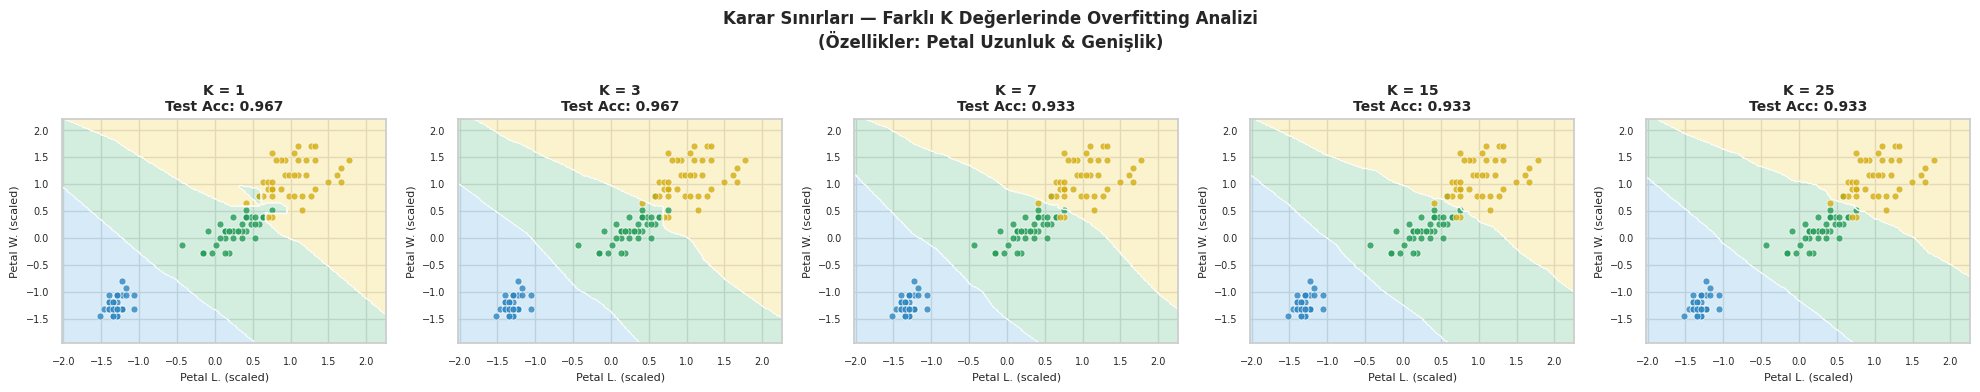


💡 K=1: Çok dalgalı sınır → Overfitting | K=25: Düz sınır → Underfitting başlangıcı


In [23]:
# ─────────────────────────────────────────────────────────────
# Karar Sınırları — Farklı K Değerleri için
# İlk iki özellik kullanılarak 2D görselleştirme
# ─────────────────────────────────────────────────────────────

# Sadece 2 özellik al (görselleştirme için 2D gerekli)
X_2d = X_train_scaled[:, 2:4]   # petal_length ve petal_width
X_test_2d = X_test_scaled[:, 2:4]

# İncelenecek K değerleri
k_list = [1, 3, 7, 15, 25]

fig, axes = plt.subplots(1, len(k_list), figsize=(20, 4))
fig.suptitle('Karar Sınırları — Farklı K Değerlerinde Overfitting Analizi\n(Özellikler: Petal Uzunluk & Genişlik)',
             fontsize=12, fontweight='bold')

# Renk haritası ve sınıf renkleri
cmap_light = mcolors.ListedColormap(['#AED6F1', '#A9DFBF', '#F9E79F'])
cmap_bold  = ['#2E86C1', '#239B56', '#D4AC0D']

# Grid nokta aralığı
h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

for ax, k in zip(axes, k_list):
    # Model kur
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_2d, y_train)

    # Tüm grid noktaları için tahmin
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Renkli arka plan (karar bölgeleri)
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.5, alpha=0.8)

    # Eğitim noktaları
    for cls, color in enumerate(cmap_bold):
        mask = y_train == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, s=25, alpha=0.8,
                   edgecolors='white', linewidth=0.5)

    # Test doğruluğu başlığa ekle
    test_acc = knn.score(X_test_2d, y_test)
    ax.set_title(f'K = {k}\nTest Acc: {test_acc:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Petal L. (scaled)', fontsize=8)
    ax.set_ylabel('Petal W. (scaled)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
print("\n💡 K=1: Çok dalgalı sınır → Overfitting | K=25: Düz sınır → Underfitting başlangıcı")

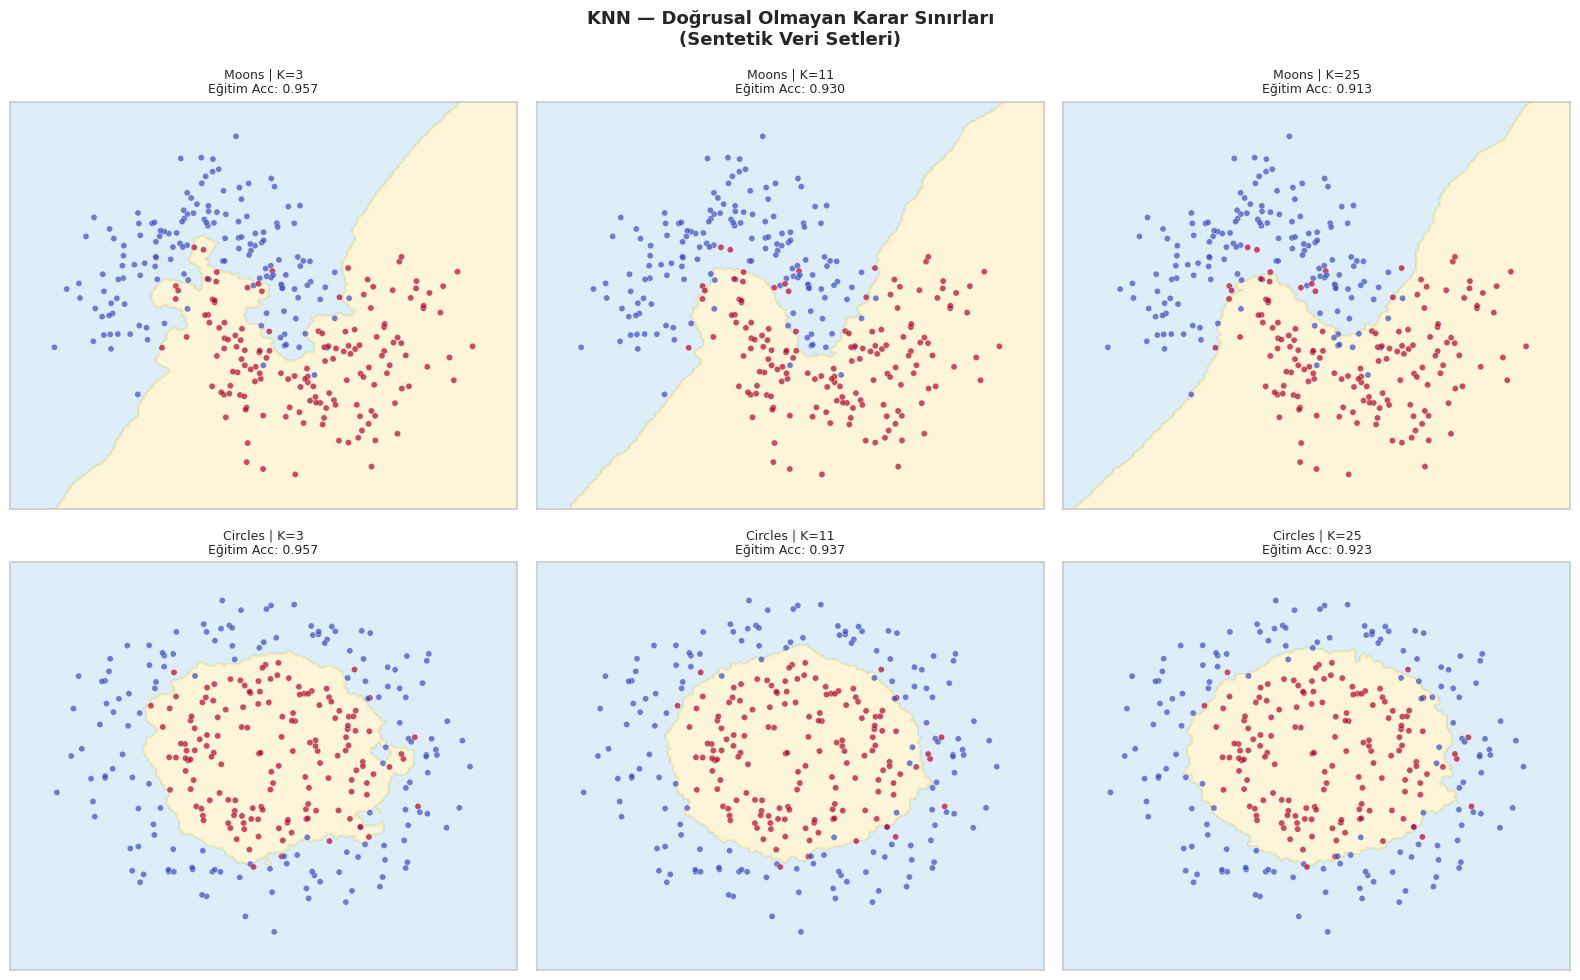

💡 KNN, doğrusal olmayan sınıflara (ay, daire) hiçbir ek düzenleme gerektirmeden uyum sağlar!


In [24]:
# ─────────────────────────────────────────────────────────────
# KNN'in Doğrusal Olmayan Sınırlara Uyumu
# Sentetik 'Moons' ve 'Circles' veri setleri
# ─────────────────────────────────────────────────────────────
# KNN'in avantajı: Doğrusal olmayan sınıflara otomatik uyum

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('KNN — Doğrusal Olmayan Karar Sınırları\n(Sentetik Veri Setleri)',
             fontsize=13, fontweight='bold')

datasets = [
    (make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE), 'Moons'),
    (make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=RANDOM_STATE), 'Circles'),
]

k_tests = [3, 11, 25]

for row, ((X_ds, y_ds), ds_name) in enumerate(datasets):
    # Veriyi ölçekle
    scaler_ds = StandardScaler()
    X_ds_s = scaler_ds.fit_transform(X_ds)

    # Grid
    x_min, x_max = X_ds_s[:, 0].min() - 0.5, X_ds_s[:, 0].max() + 0.5
    y_min, y_max = X_ds_s[:, 1].min() - 0.5, X_ds_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    for col, k in enumerate(k_tests):
        ax = axes[row][col]

        # Model
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_ds_s, y_ds)
        Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        # Görselleştir
        ax.contourf(xx, yy, Z, alpha=0.4,
                    cmap=mcolors.ListedColormap(['#AED6F1', '#F9E79F']))

        # Veri noktaları
        scatter = ax.scatter(X_ds_s[:, 0], X_ds_s[:, 1],
                             c=y_ds, cmap='coolwarm', s=20, alpha=0.7,
                             edgecolors='white', linewidth=0.3)

        train_acc = knn.score(X_ds_s, y_ds)
        ax.set_title(f'{ds_name} | K={k}\nEğitim Acc: {train_acc:.3f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
print("💡 KNN, doğrusal olmayan sınıflara (ay, daire) hiçbir ek düzenleme gerektirmeden uyum sağlar!")

---
## 13. Uzaklık Metriklerinin Karşılaştırması

In [25]:
# ─────────────────────────────────────────────────────────────
# Farklı Uzaklık Metriklerinin Performans Karşılaştırması
# K=5 ile sabit tutarak sadece metrik değiştirilir
# ─────────────────────────────────────────────────────────────

metrics_to_test = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
p_values = {'minkowski': 3}  # p=3 Minkowski için

results = []

for metric in metrics_to_test:
    for k in [3, 5, 7, 11, 15]:
        params = {'n_neighbors': k, 'metric': metric, 'n_jobs': -1}

        # Minkowski için p değeri ekle
        if metric == 'minkowski':
            params['p'] = 3

        knn = KNeighborsClassifier(**params)
        knn.fit(X_train_scaled, y_train)

        # 5-katlı CV
        cv_acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, n_jobs=-1).mean()
        test_acc = knn.score(X_test_scaled, y_test)

        results.append({
            'Metrik': metric,
            'K': k,
            'CV Doğruluğu': round(cv_acc, 4),
            'Test Doğruluğu': round(test_acc, 4)
        })

df_metrics = pd.DataFrame(results)

# En iyi kombinasyonu bul
best_row = df_metrics.loc[df_metrics['CV Doğruluğu'].idxmax()]
print("=" * 50)
print("En İyi Kombinasyon (CV'ye göre):")
print(f"  Metrik: {best_row['Metrik']}, K: {best_row['K']}")
print(f"  CV Doğruluğu: {best_row['CV Doğruluğu']:.4f}")
print(f"  Test Doğruluğu: {best_row['Test Doğruluğu']:.4f}")
print("=" * 50)

En İyi Kombinasyon (CV'ye göre):
  Metrik: euclidean, K: 5
  CV Doğruluğu: 0.9667
  Test Doğruluğu: 0.9333


In [26]:
# ─────────────────────────────────────────────────────────────
# Plotly ile Metrik × K Isı Haritası
# ─────────────────────────────────────────────────────────────

# Pivot tablo: satırlar=K, sütunlar=Metrik
pivot = df_metrics.pivot(index='K', columns='Metrik', values='Test Doğruluğu')

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=[str(k) for k in pivot.index],
    colorscale='RdYlGn',
    zmin=0.85, zmax=1.0,
    text=[[f'{v:.3f}' for v in row] for row in pivot.values],
    texttemplate='%{text}',
    textfont={'size': 12},
    hoverongaps=False
))

fig.update_layout(
    title=dict(text='Uzaklık Metriği × K Değeri — Test Doğruluğu Isı Haritası', x=0.5),
    xaxis_title='Uzaklık Metriği',
    yaxis_title='K Değeri',
    height=350,
    template='plotly_white'
)

fig.show()
print("💡 Açık yeşil = yüksek doğruluk; kırmızı = düşük doğruluk")

💡 Açık yeşil = yüksek doğruluk; kırmızı = düşük doğruluk


---
## 14. Özellik Ölçeklendirmenin Önemi

KNN için ölçeklendirme **neden şart?** Bunu somut sayılarla kanıtlayalım.  
Wine veri setini kullanacağız çünkü özelliklerin ölçek farklılıkları çok belirgindir.

In [27]:
# ─────────────────────────────────────────────────────────────
# Wine Veri Seti ile Ölçeklendirme Önemi Demosu
# ─────────────────────────────────────────────────────────────

# Wine veri setini yükle
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# Train-test split
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=RANDOM_STATE, stratify=y_wine
)

# Ham verinin ölçek farklılıklarını göster
print("Wine Veri Seti — Özellik Ölçekleri:")
df_wine_info = pd.DataFrame({
    'Özellik': wine.feature_names,
    'Min': X_wine.min(axis=0).round(3),
    'Max': X_wine.max(axis=0).round(3),
    'Ortalama': X_wine.mean(axis=0).round(3),
    'Std': X_wine.std(axis=0).round(3)
})
print(df_wine_info.to_string(index=False))

Wine Veri Seti — Özellik Ölçekleri:
                     Özellik    Min     Max  Ortalama     Std
                     alcohol  11.03   14.83    13.001   0.810
                  malic_acid   0.74    5.80     2.336   1.114
                         ash   1.36    3.23     2.367   0.274
           alcalinity_of_ash  10.60   30.00    19.495   3.330
                   magnesium  70.00  162.00    99.742  14.242
               total_phenols   0.98    3.88     2.295   0.624
                  flavanoids   0.34    5.08     2.029   0.996
        nonflavanoid_phenols   0.13    0.66     0.362   0.124
             proanthocyanins   0.41    3.58     1.591   0.571
             color_intensity   1.28   13.00     5.058   2.312
                         hue   0.48    1.71     0.957   0.228
od280/od315_of_diluted_wines   1.27    4.00     2.612   0.708
                     proline 278.00 1680.00   746.893 314.022


In [28]:
# ─────────────────────────────────────────────────────────────
# Ölçeklendirme Yok vs StandardScaler vs MinMaxScaler Karşılaştırması
# ─────────────────────────────────────────────────────────────

# 1. Ölçeklendirme YOK
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_w_train, y_w_train)
acc_raw = knn_raw.score(X_w_test, y_w_test)

# 2. StandardScaler (Z-score)
std_scaler = StandardScaler()
X_w_train_std = std_scaler.fit_transform(X_w_train)
X_w_test_std  = std_scaler.transform(X_w_test)
knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_w_train_std, y_w_train)
acc_std = knn_std.score(X_w_test_std, y_w_test)

# 3. MinMaxScaler (0-1 aralığı)
mm_scaler = MinMaxScaler()
X_w_train_mm = mm_scaler.fit_transform(X_w_train)
X_w_test_mm  = mm_scaler.transform(X_w_test)
knn_mm = KNeighborsClassifier(n_neighbors=5)
knn_mm.fit(X_w_train_mm, y_w_train)
acc_mm = knn_mm.score(X_w_test_mm, y_w_test)

# Sonuçları görselleştir
fig = px.bar(
    x=['Ölçeklendirme Yok', 'StandardScaler (Z-score)', 'MinMaxScaler (0-1)'],
    y=[acc_raw, acc_std, acc_mm],
    color=['Ölçeklendirme Yok', 'StandardScaler (Z-score)', 'MinMaxScaler (0-1)'],
    text=[f'{v:.3f}' for v in [acc_raw, acc_std, acc_mm]],
    title='Wine Veri Seti — KNN Doğruluğu: Ölçeklendirmenin Etkisi (K=5)',
    labels={'x': 'Ölçeklendirme Yöntemi', 'y': 'Test Doğruluğu'},
    color_discrete_sequence=['#e74c3c', '#2ecc71', '#3498db']
)
fig.update_traces(textposition='outside')
fig.update_layout(
    yaxis=dict(range=[0, 1.1]), height=380,
    showlegend=False, template='plotly_white'
)
fig.add_hline(y=1.0, line_dash='dot', line_color='gray')
fig.show()

print(f"\nÖlçeklendirme YOK    → Doğruluk: {acc_raw:.4f}")
print(f"StandardScaler       → Doğruluk: {acc_std:.4f}  (+{(acc_std-acc_raw)*100:.1f} puan)")
print(f"MinMaxScaler         → Doğruluk: {acc_mm:.4f}  (+{(acc_mm-acc_raw)*100:.1f} puan)")
print("\n⚠️  ÇIKARIM: Ölçeklendirme olmadan KNN ciddi performans kaybı yaşar!")


Ölçeklendirme YOK    → Doğruluk: 0.8056
StandardScaler       → Doğruluk: 0.9722  (+16.7 puan)
MinMaxScaler         → Doğruluk: 1.0000  (+19.4 puan)

⚠️  ÇIKARIM: Ölçeklendirme olmadan KNN ciddi performans kaybı yaşar!


---
## 15. KNN ile Regresyon

KNN sadece sınıflandırma için değil, **sayısal değer tahmini** (regresyon) için de kullanılabilir.  
Fark yalnızca tahmin adımındadır:

$$\hat{y} = \frac{1}{K} \sum_{i \in N_K(x)} y_i \quad \text{(eşit ağırlıklı)}$$

$$\hat{y} = \frac{\sum_{i \in N_K(x)} w_i \cdot y_i}{\sum_{i \in N_K(x)} w_i} \quad \text{(ağırlıklı, } w_i = 1/d_i)$$

In [29]:
# ─────────────────────────────────────────────────────────────
# KNN Regresyon — 1D Örnek (Sinüs + Gürültü)
# ─────────────────────────────────────────────────────────────

np.random.seed(RANDOM_STATE)

# Sinüs eğrisi + Gaussian gürültüsü
n_samples = 200
X_reg = np.sort(np.random.uniform(-6, 6, n_samples)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.3, n_samples)

# Train-test split
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

# Tahmin için düzgün bir x aralığı
X_plot = np.linspace(-6.5, 6.5, 500).reshape(-1, 1)

# Farklı K değerleri ile regresyon
k_reg_list = [1, 5, 15, 50]

# Her K için renk
colors_reg = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig = go.Figure()

# Gerçek sinüs eğrisi (referans)
fig.add_trace(go.Scatter(
    x=X_plot.ravel(),
    y=np.sin(X_plot).ravel(),
    mode='lines',
    line=dict(color='black', dash='dot', width=2),
    name='Gerçek Fonksiyon: sin(x)'
))

# Eğitim veri noktaları
fig.add_trace(go.Scatter(
    x=X_r_train.ravel(),
    y=y_r_train,
    mode='markers',
    marker=dict(color='rgba(150,150,150,0.5)', size=5),
    name='Eğitim Verisi'
))

# Her K için KNN tahmin eğrisi
for k, color in zip(k_reg_list, colors_reg):
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights='uniform')
    knn_reg.fit(X_r_train, y_r_train)

    y_plot = knn_reg.predict(X_plot)    # Tahmin eğrisi için
    y_pred = knn_reg.predict(X_r_test)  # Test metrikleri için

    rmse = np.sqrt(mean_squared_error(y_r_test, y_pred))  # RMSE hesapla
    r2   = r2_score(y_r_test, y_pred)                     # R² hesapla

    fig.add_trace(go.Scatter(
        x=X_plot.ravel(),
        y=y_plot,
        mode='lines',
        line=dict(color=color, width=2.5),
        name=f'K={k}  RMSE={rmse:.3f}  R²={r2:.3f}'
    ))

fig.update_layout(
    title=dict(text='KNN Regresyon — Farklı K Değerleri (sin(x) + gürültü)', x=0.5),
    xaxis_title='x', yaxis_title='y',
    height=450, template='plotly_white',
    legend=dict(orientation='v', x=1.01, xanchor='left')
)
fig.show()
print("\n💡 K=1: Gürültülü veriyi ezberliyor | K=50: Aşırı düzleşiyor")


💡 K=1: Gürültülü veriyi ezberliyor | K=50: Aşırı düzleşiyor


---
## 16. Gerçek Dünya Uygulaması: Wine Kalite Sınıflandırması

Bu bölümde şimdiye kadar öğrendiklerimizi bütünleşik bir şekilde uygulayacağız.  
**Kaynak:** UCI ML Repository — Wine veri seti (Forina et al., 1986)

In [30]:
# ─────────────────────────────────────────────────────────────
# Wine Veri Seti — Eksiksiz KNN Pipeline
# ─────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

# Veri seti bilgileri
print("WINE VERİ SETİ:")
print(f"  Kaynak   : UCI ML Repository")
print(f"  URL      : https://archive.ics.uci.edu/ml/datasets/wine")
print(f"  Örnekler : {wine.data.shape[0]}")
print(f"  Özellikler: {wine.data.shape[1]} (kimyasal analiz sonuçları)")
print(f"  Sınıflar : {list(wine.target_names)}")
print()

# Pipeline oluştur: Ölçeklendirme + KNN
# Pipeline'ın avantajı: fit ve predict adımları otomatik zincirlenir
# Veri sızıntısını (data leakage) önler
pipeline = Pipeline([
    ('scaler', StandardScaler()),          # Adım 1: Ölçeklendir
    ('knn', KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',                # Ağırlıklı oy
        metric='euclidean',
        n_jobs=-1
    ))
])

# Fit ve değerlendir
pipeline.fit(X_w_train, y_w_train)
y_wine_pred = pipeline.predict(X_w_test)
wine_acc = pipeline.score(X_w_test, y_w_test)

print(f"Pipeline Test Doğruluğu: {wine_acc:.4f} ({wine_acc*100:.1f}%)")
print()
print(classification_report(y_w_test, y_wine_pred,
                             target_names=wine.target_names, digits=3))

WINE VERİ SETİ:
  Kaynak   : UCI ML Repository
  URL      : https://archive.ics.uci.edu/ml/datasets/wine
  Örnekler : 178
  Özellikler: 13 (kimyasal analiz sonuçları)
  Sınıflar : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Pipeline Test Doğruluğu: 1.0000 (100.0%)

              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



In [31]:
# ─────────────────────────────────────────────────────────────
# Wine — Özellik Önem Analizi (Permütasyon Bazlı)
# ─────────────────────────────────────────────────────────────
# KNN parametrik olmadığından doğrudan özellik önemi yoktur.
# Permütasyon yöntemi: Bir özelliği boz → doğruluk düşerse önemlidir.

from sklearn.inspection import permutation_importance

# Pipeline içindeki KNN için permütasyon önemi hesapla
X_w_test_scaled_pipe = pipeline.named_steps['scaler'].transform(X_w_test)
knn_in_pipe = pipeline.named_steps['knn']

perm_imp = permutation_importance(
    knn_in_pipe, X_w_test_scaled_pipe, y_w_test,
    n_repeats=30,       # Her özellik için 30 kez karıştır
    random_state=RANDOM_STATE,
    scoring='accuracy',
    n_jobs=-1
)

# Önem sırasına göre sırala
feat_importance = pd.DataFrame({
    'Özellik': wine.feature_names,
    'Önem': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Önem', ascending=True)

# Altair horizontal bar chart
chart_imp = alt.Chart(feat_importance).mark_bar(color='#2196F3', opacity=0.8).encode(
    x=alt.X('Önem:Q', title='Permütasyon Önemi (Doğruluk Düşüşü)'),
    y=alt.Y('Özellik:N', sort=None, title='Özellik'),
    tooltip=['Özellik:N', alt.Tooltip('Önem:Q', format='.4f')]
).properties(
    width=500, height=350,
    title='KNN — Wine Veri Seti Özellik Önemleri (Permütasyon)'
)

chart_imp.configure_title(fontSize=13).show()

top3 = feat_importance.nlargest(3, 'Önem')['Özellik'].tolist()
print(f"\n🏆 En önemli 3 özellik: {top3}")

alt.Chart(...)


🏆 En önemli 3 özellik: ['proline', 'alcohol', 'flavanoids']


---
## 17. Avantajlar, Dezavantajlar ve Ne Zaman Kullanılır?

### Avantajlar

| Avantaj | Açıklama |
|---------|----------|
| **Basitlik** | Uygulama ve anlama çok kolay; matematiksel varsayım yok |
| **Parametrik olmayan** | Veri dağılımı hakkında varsayım gerekmez |
| **Doğrusal olmayan sınırlar** | Karmaşık karar sınırlarını otomatik öğrenir |
| **Sıfır eğitim süresi** | Eğitim = veriyi sakla → O(1) |
| **Yeni veri adaptasyonu** | Yeni eğitim verisi eklemek modeli yeniden kurmayı gerektirmez |
| **Çok sınıflı** | Doğal olarak 2'den fazla sınıfı destekler |

### Dezavantajlar

| Dezavantaj | Açıklama |
|------------|----------|
| **Yüksek tahmin maliyeti** | Her tahmin için tüm eğitim setini tarıyor → O(n·d) |
| **Bellek kullanımı** | Tüm eğitim verisi saklanmalı |
| **Boyut laneti** | Yüksek boyutlarda uzaklıklar anlamsızlaşır |
| **Ölçeklendirme zorunluluğu** | Özellik ölçekleri eşitlenmezse hatalı sonuç |
| **Dengesiz sınıf** | Büyük sınıf küçük sınıfı domine eder |
| **Gürültüye duyarlılık** | Aykırı değerler k=1 durumunda baskın olabilir |
| **Kategorik değişkenler** | Ham kategorik veriler doğrudan kullanılamaz |

---

### Ne Zaman KNN Kullanılır?

**Uygun senaryolar:**
- Küçük-orta büyüklükte veri seti (< ~100.000 örnek)
- Hızlı prototipleme / baseline model
- Öneri sistemleri (collaborative filtering)
- Anomali tespiti
- Özellikler arasındaki ilişki doğrusal değilse

**Uygun olmayan senaryolar:**
- Çok yüksek boyutlu veriler (görüntü, metin — ham halde)
- Gerçek zamanlı tahmin gerektiren uygulamalar
- Büyük veri setleri (> 1 milyon örnek)
- Yorumlanabilirlik kritik öneme sahipse (kararlar açıklanamaz)

### Boyut Laneti (Curse of Dimensionality):

Özellik sayısı arttıkça tüm noktalar birbirine benzer mesafede olmaya başlar:

$$\lim_{d \to \infty} \frac{d_{max} - d_{min}}{d_{min}} \to 0$$

Bu durumda "en yakın komşu" kavramı anlamsızlaşır. **Çözümler:** Boyut indirgeme (PCA, t-SNE), özellik seçimi.

In [32]:
# ─────────────────────────────────────────────────────────────
# Boyut Laneti — Sayısal Demonstrasyon
# Boyut artıkça max ve min mesafe arasındaki fark nasıl daralıyor?
# ─────────────────────────────────────────────────────────────

np.random.seed(RANDOM_STATE)
n_points = 1000    # Her deneyde 1000 rastgele nokta üret
dimensions = [1, 2, 5, 10, 20, 50, 100, 200, 500]

ratios = []   # (max_dist - min_dist) / min_dist oranı

for d in dimensions:
    # d-boyutlu birim hiperkübde rastgele noktalar
    points = np.random.uniform(0, 1, (n_points, d))

    # Referans noktası (orijin)
    ref = np.zeros(d)

    # Tüm noktalara Öklid mesafelerini hesapla
    dists = np.sqrt(np.sum((points - ref) ** 2, axis=1))

    # Oranı hesapla
    ratio = (dists.max() - dists.min()) / (dists.min() + 1e-10)
    ratios.append(ratio)

# Plotly çizgi grafiği
fig = px.line(
    x=dimensions, y=ratios,
    markers=True,
    title='Boyut Laneti: Boyut Artıkça Uzaklıklar Anlamsızlaşıyor',
    labels={'x': 'Boyut Sayısı (d)', 'y': '(d_max - d_min) / d_min'}
)
fig.update_traces(line=dict(color='#e74c3c', width=3),
                  marker=dict(size=10, symbol='circle'))
fig.update_layout(
    height=400, template='plotly_white',
    annotations=[dict(
        x=200, y=ratios[dimensions.index(200)]+0.5,
        text='Oran küçüldükçe<br>"yakın" ve "uzak" anlamını yitirir',
        showarrow=True, arrowhead=2
    )]
)
fig.show()
print("\n💡 Yüksek boyutlarda KNN'den önce boyut indirgeme (PCA vb.) yapılmalıdır.")


💡 Yüksek boyutlarda KNN'den önce boyut indirgeme (PCA vb.) yapılmalıdır.


---
## 18. Özet ve Sonraki Adımlar

### Bu Derste Öğrendiklerimiz:

| Konu | Ana Çıkarım |
|------|-------------|
| KNN Algoritması | Tembel öğrenme: eğitim = veri saklama, tahmin = uzaklık hesabı |
| Uzaklık Metrikleri | Öklid en yaygın; seçim veri tipine göre yapılmalı |
| K Değeri | Overfitting/underfitting dengesi; CV ile seçilmeli |
| Ölçeklendirme | **Zorunlu!** Olmadan KNN büyük ölçekli özelliklere domine edilir |
| Karar Sınırları | Küçük K → karmaşık sınır, büyük K → düz sınır |
| Boyut Laneti | Yüksek boyutlarda önce boyut indirgeme yapılmalı |
| Pipeline | Ölçeklendirme + model birlikte sarılmalı — veri sızıntısını önler |

---

### Pratik Kurallar:

1. **Her zaman ölçeklendir** — `StandardScaler` ya da `MinMaxScaler`
2. **K'yı CV ile seç** — Test setine bakma!
3. **K'yı tek sayı yap** — İkili sınıflandırmada beraberliği önler
4. **Büyük veri setlerinde** KD-Tree veya Ball-Tree hızlandırması kullan
5. **Yüksek boyutlarda** önce PCA uygula

---

### Sonraki Hafta: Lojistik Regresyon

KNN'den sonraki adım, **parametrik** bir model olan Lojistik Regresyon. Karşılaştırma:

| Özellik | KNN | Lojistik Regresyon |
|---------|-----|--------------------|
| Öğrenme türü | Tembel (Lazy) | Aktif (Eager) |
| Yorumlanabilirlik | Düşük | **Yüksek** (katsayılar) |
| Eğitim hızı | Hızlı | Orta |
| Tahmin hızı | Yavaş | **Hızlı** |
| Doğrusal olmayan | Evet | Hayır (ham halde) |
| Olasılık çıktısı | Yaklaşık | **Gerçek** |

---

### Ek Kaynaklar:

- **Kitap:** Aurélien Géron — *Hands-On Machine Learning* (3. Baskı), Bölüm 3
- **Scikit-learn:** https://scikit-learn.org/stable/modules/neighbors.html
- **UCI Repository:** https://archive.ics.uci.edu/ml/datasets/iris
- **Makale:** Cover & Hart (1967) — *"Nearest Neighbor Pattern Classification"*, IEEE Trans.
- **Interaktif görsel:** https://cs.stanford.edu/~karpathy/svmjs/demo/demonn.html

In [33]:
# ─────────────────────────────────────────────────────────────
# DERS SONU: Tüm Sonuçların Özeti
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("   KNN DERS ÖZETI — SONUÇLAR")
print("=" * 60)
print()
print("Iris Veri Seti (150 örnek, 4 özellik, 3 sınıf):")
print(f"   Sıfırdan KNN (K=5, Öklid)   : {acc_scratch*100:.1f}%")
print(f"   Sklearn KNN (K=5, Öklid)    : {acc_sklearn*100:.1f}%")
print(f"   GridSearchCV en iyi model   : {grid_search.best_estimator_.score(X_test_scaled, y_test)*100:.1f}%")
print(f"   En iyi parametreler         : {grid_search.best_params_}")
print()
print("Wine Veri Seti (178 örnek, 13 özellik, 3 sınıf):")
print(f"   Ölçeklendirme YOK (K=5)     : {acc_raw*100:.1f}%")
print(f"   StandardScaler (K=5)        : {acc_std*100:.1f}%  ← +{(acc_std-acc_raw)*100:.1f} puan")
print(f"   MinMaxScaler (K=5)          : {acc_mm*100:.1f}%  ← +{(acc_mm-acc_raw)*100:.1f} puan")
print(f"   Pipeline (K=7, ağırlıklı)   : {wine_acc*100:.1f}%")
print()
print("Ana Çıkarımlar:")
print("   1. Ölçeklendirme KNN için zorunludur!")
print("   2. K değerini cross-validation ile seç")
print("   3. Ağırlıklı oy genellikle uniform'dan iyidir")
print("   4. Pipeline kullan — veri sızıntısını önler")
print()
print("=" * 60)
print("   Sonraki Ders: Lojistik Regresyon")
print("=" * 60)

   KNN DERS ÖZETI — SONUÇLAR

Iris Veri Seti (150 örnek, 4 özellik, 3 sınıf):
   Sıfırdan KNN (K=5, Öklid)   : 93.3%
   Sklearn KNN (K=5, Öklid)    : 93.3%
   GridSearchCV en iyi model   : 96.7%
   En iyi parametreler         : {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}

Wine Veri Seti (178 örnek, 13 özellik, 3 sınıf):
   Ölçeklendirme YOK (K=5)     : 80.6%
   StandardScaler (K=5)        : 97.2%  ← +16.7 puan
   MinMaxScaler (K=5)          : 100.0%  ← +19.4 puan
   Pipeline (K=7, ağırlıklı)   : 100.0%

Ana Çıkarımlar:
   1. Ölçeklendirme KNN için zorunludur!
   2. K değerini cross-validation ile seç
   3. Ağırlıklı oy genellikle uniform'dan iyidir
   4. Pipeline kullan — veri sızıntısını önler

   Sonraki Ders: Lojistik Regresyon
